# 🤖 Notebook 4: Entrenamiento y Ajuste de Modelos
## Dataset: Medical Cost Personal Dataset

**Objetivo:** Entrenar y ajustar los tres modelos de regresión con búsqueda de hiperparámetros.

**Modelos:**
1. 📈 Regresión Lineal (LinearRegression + Ridge + Lasso)
2. 🔵 K-Nearest Neighbors Regressor (KNN)
3. 🌲 Random Forest Regressor

**Búsqueda de hiperparámetros:** GridSearchCV + RandomizedSearchCV

**Métricas:** RMSE, MSE, MAE, R²

In [1]:
# ─────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, warnings, time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from scipy.stats import randint, uniform

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

def rmse(y_true, y_pred): 
    return np.sqrt(mean_squared_error(y_true, y_pred))

def get_metrics(y_true, y_pred, label=''):
    return {
        'Model': label,
        'RMSE':  rmse(y_true, y_pred),
        'MSE':   mean_squared_error(y_true, y_pred),
        'MAE':   mean_absolute_error(y_true, y_pred),
        'R2':    r2_score(y_true, y_pred)
    }

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga de Datos

In [2]:
# Datos con features seleccionadas
X_train = pd.read_csv('../data/processed/X_train_selected.csv')
X_test  = pd.read_csv('../data/processed/X_test_selected.csv')
X_train_sc = pd.read_csv('../data/processed/X_train_scaled_selected.csv')
X_test_sc  = pd.read_csv('../data/processed/X_test_scaled_selected.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
y_raw_train = pd.read_csv('../data/processed/y_raw_train.csv').squeeze()
y_raw_test  = pd.read_csv('../data/processed/y_raw_test.csv').squeeze()

with open('../data/processed/feature_info.json') as f:
    feature_info = json.load(f)

print(f'📦 X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'🎯 Target: {feature_info["target"]} (log-transformado)')
print(f'📋 Features: {list(X_train.columns)}')

# Configuración de CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
print('\n⚙️  Cross-Validation: KFold(n_splits=5, shuffle=True)')

📦 X_train: (1069, 7) | X_test: (268, 7)
🎯 Target: log_charges (log-transformado)
📋 Features: ['bmi_smoker', 'age', 'smoker_enc', 'age_smoker', 'age_group_senior', 'age_group_young', 'bmi']

⚙️  Cross-Validation: KFold(n_splits=5, shuffle=True)


## 2. Modelo 1: Regresión Lineal

In [3]:
# ─────────────────────────────────────────
# REGRESIÓN LINEAL — Baseline
# ─────────────────────────────────────────
print('='*60)
print('📈 MODELO 1: REGRESIÓN LINEAL')
print('='*60)

# Modelo baseline (sin regularización)
lr_base = LinearRegression()
lr_base.fit(X_train_sc, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'Feature': X_train_sc.columns,
    'Coeficiente': lr_base.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print('\n📊 Coeficientes del modelo (ordenados por importancia):')
print(coef_df.round(4).to_string(index=False))
print(f'\n  Intercepto: {lr_base.intercept_:.4f}')

📈 MODELO 1: REGRESIÓN LINEAL

📊 Coeficientes del modelo (ordenados por importancia):
         Feature  Coeficiente
      smoker_enc       1.2187
      bmi_smoker       0.6470
             age       0.5920
      age_smoker      -0.5440
age_group_senior      -0.0837
 age_group_young      -0.0700
             bmi      -0.0075

  Intercepto: 8.9023


In [ ]:
# ─────────────────────────────────────────
# GRID SEARCH — Ridge y Lasso
# ─────────────────────────────────────────
print('\n🔍 GridSearchCV — Ridge:')
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]}
ridge_gs = GridSearchCV(Ridge(), ridge_params, cv=cv,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train_sc, y_train)
print(f'  Mejor alpha Ridge: {ridge_gs.best_params_["alpha"]}')
print(f'  Mejor RMSE CV: {-ridge_gs.best_score_:.4f}')

print('\n🔍 GridSearchCV — Lasso:')
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1]}
lasso_gs = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=cv,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train_sc, y_train)
print(f'  Mejor alpha Lasso: {lasso_gs.best_params_["alpha"]}')
print(f'  Mejor RMSE CV: {-lasso_gs.best_score_:.4f}')

# Mejor modelo lineal
best_lr = ridge_gs.best_estimator_
y_pred_lr_train = best_lr.predict(X_train_sc)
y_pred_lr_test  = best_lr.predict(X_test_sc)

# Convertir predicciones de log a escala original
y_pred_lr_train_raw = np.expm1(y_pred_lr_train)
y_pred_lr_test_raw  = np.expm1(y_pred_lr_test)

metrics_lr_train = get_metrics(y_raw_train, y_pred_lr_train_raw, 'LinReg (Train)')
metrics_lr_test  = get_metrics(y_raw_test, y_pred_lr_test_raw, 'LinReg (Test)')

print(f'\n📊 Métricas en escala original ($):')
print(f'  TRAIN → RMSE: {metrics_lr_train["RMSE"]:,.2f} | R²: {metrics_lr_train["R2"]:.4f}')
print(f'  TEST  → RMSE: {metrics_lr_test["RMSE"]:,.2f} | R²: {metrics_lr_test["R2"]:.4f}')


🔍 GridSearchCV — Ridge:


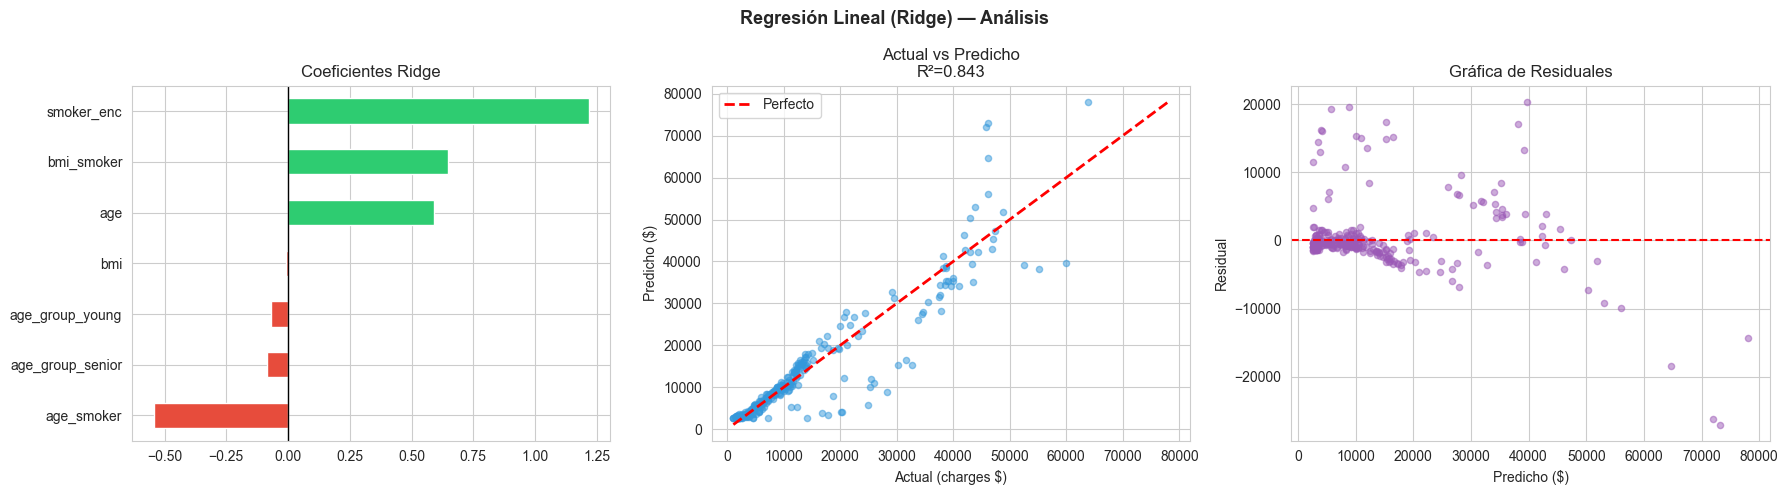

In [ ]:
# Visualización de coeficientes y residuales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regresión Lineal (Ridge) — Análisis', fontsize=13, fontweight='bold')

# Coeficientes
best_coefs = pd.Series(best_lr.coef_, index=X_train_sc.columns).sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in best_coefs]
best_coefs.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Coeficientes Ridge')
axes[0].axvline(x=0, color='black', linewidth=1)

# Predicted vs Actual
axes[1].scatter(y_raw_test, y_pred_lr_test_raw, alpha=0.5, s=20, color='#3498db')
lims = [min(y_raw_test.min(), y_pred_lr_test_raw.min()),
        max(y_raw_test.max(), y_pred_lr_test_raw.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Perfecto')
axes[1].set_xlabel('Actual (charges $)')
axes[1].set_ylabel('Predicho ($)')
axes[1].set_title(f'Actual vs Predicho\nR²={metrics_lr_test["R2"]:.3f}')
axes[1].legend()

# Residuales
residuals = y_raw_test.values - y_pred_lr_test_raw
axes[2].scatter(y_pred_lr_test_raw, residuals, alpha=0.5, s=20, color='#9b59b6')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_xlabel('Predicho ($)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Gráfica de Residuales')

plt.tight_layout()
plt.savefig('../data/processed/lr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modelo 2: K-Nearest Neighbors (KNN)

🔵 MODELO 2: K-NEAREST NEIGHBORS (KNN)

📊 K óptimo (menor RMSE CV): k = 30
   RMSE CV con k=30: 0.4303


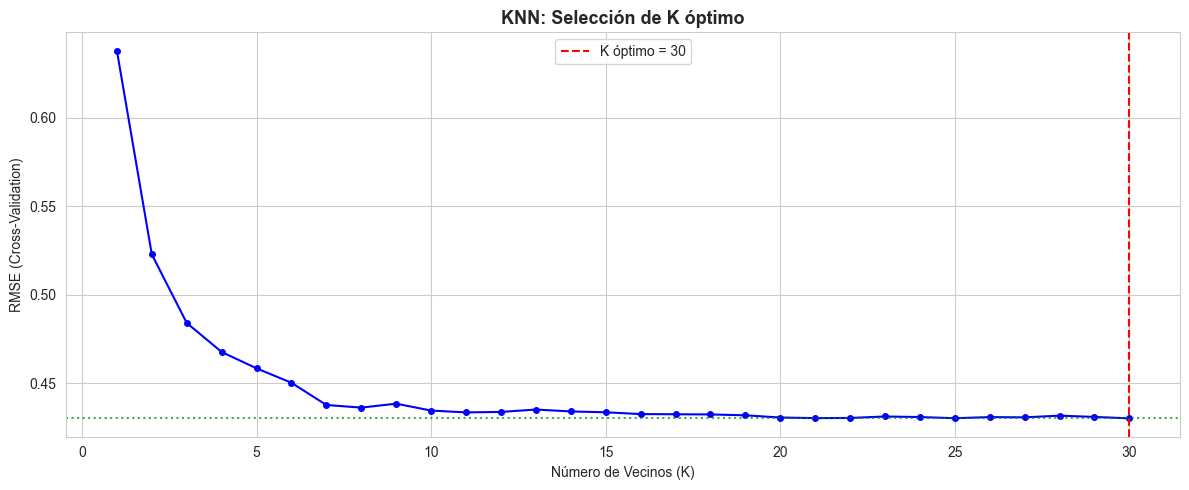

In [ ]:
# ─────────────────────────────────────────
# KNN REGRESSOR
# ─────────────────────────────────────────
print('='*60)
print('🔵 MODELO 2: K-NEAREST NEIGHBORS (KNN)')
print('='*60)

# Análisis del número óptimo de K
k_range = range(1, 31)
knn_cv_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, 
                             cv=cv, scoring='neg_root_mean_squared_error')
    knn_cv_scores.append(-scores.mean())

optimal_k = k_range[np.argmin(knn_cv_scores)]
print(f'\n📊 K óptimo (menor RMSE CV): k = {optimal_k}')
print(f'   RMSE CV con k={optimal_k}: {min(knn_cv_scores):.4f}')

# Curva de K vs RMSE
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, knn_cv_scores, 'b-o', markersize=4, linewidth=1.5)
ax.axvline(x=optimal_k, color='red', linestyle='--', 
           label=f'K óptimo = {optimal_k}')
ax.axhline(y=min(knn_cv_scores), color='green', linestyle=':', alpha=0.7)
ax.set_xlabel('Número de Vecinos (K)')
ax.set_ylabel('RMSE (Cross-Validation)')
ax.set_title('KNN: Selección de K óptimo', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/knn_k_selection.png', dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────
# GRID SEARCH KNN — Hiperparámetros completos
# ─────────────────────────────────────────
print('🔍 GridSearchCV — KNN:')
knn_params = {
    'n_neighbors': range(max(1, optimal_k-5), optimal_k+6),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn_gs = GridSearchCV(
    KNeighborsRegressor(), knn_params,
    cv=cv, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
knn_gs.fit(X_train_sc, y_train)

print(f'  Mejores parámetros: {knn_gs.best_params_}')
print(f'  Mejor RMSE CV: {-knn_gs.best_score_:.4f}')

# Predicciones
best_knn = knn_gs.best_estimator_
y_pred_knn_train = np.expm1(best_knn.predict(X_train_sc))
y_pred_knn_test  = np.expm1(best_knn.predict(X_test_sc))

metrics_knn_train = get_metrics(y_raw_train, y_pred_knn_train, 'KNN (Train)')
metrics_knn_test  = get_metrics(y_raw_test, y_pred_knn_test, 'KNN (Test)')

print(f'\n📊 Métricas en escala original ($):')
print(f'  TRAIN → RMSE: {metrics_knn_train["RMSE"]:,.2f} | R²: {metrics_knn_train["R2"]:.4f}')
print(f'  TEST  → RMSE: {metrics_knn_test["RMSE"]:,.2f} | R²: {metrics_knn_test["R2"]:.4f}')

🔍 GridSearchCV — KNN:
  Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 31, 'p': 1, 'weights': 'uniform'}
  Mejor RMSE CV: 0.4249

📊 Métricas en escala original ($):
  TRAIN → RMSE: 4,925.22 | R²: 0.8228
  TEST  → RMSE: 4,664.80 | R²: 0.8816


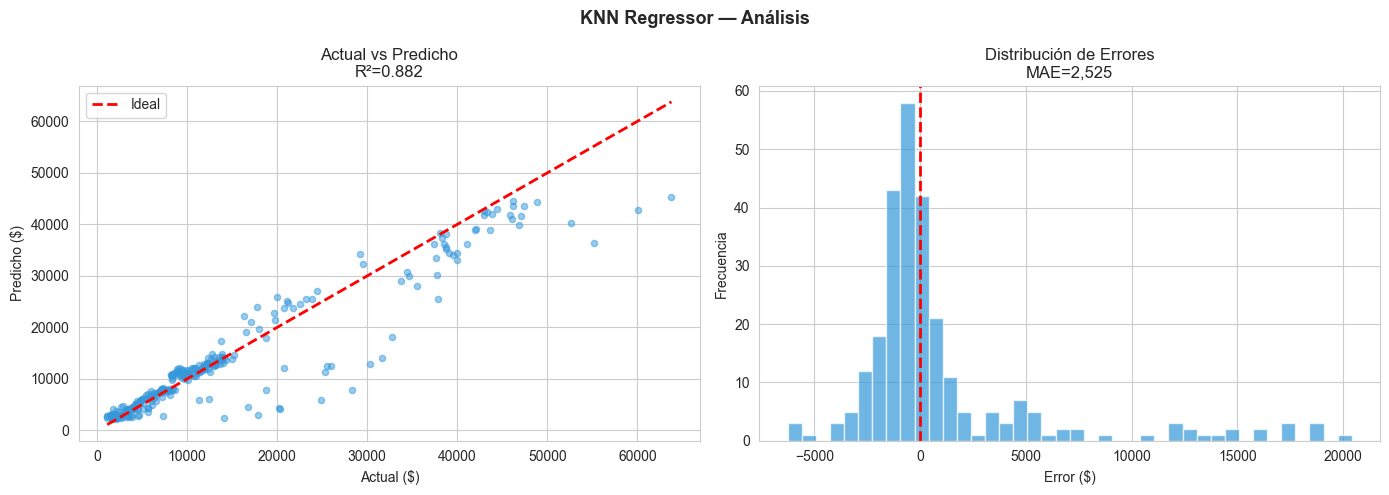

In [ ]:
# Visualización KNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN Regressor — Análisis', fontsize=13, fontweight='bold')

# Actual vs Predicho
axes[0].scatter(y_raw_test, y_pred_knn_test, alpha=0.5, s=20, color='#3498db')
lims = [min(y_raw_test.min(), y_pred_knn_test.min()),
        max(y_raw_test.max(), y_pred_knn_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Ideal')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicho ($)')
axes[0].set_title(f'Actual vs Predicho\nR²={metrics_knn_test["R2"]:.3f}')
axes[0].legend()

# Distribución de errores
errors_knn = y_raw_test.values - y_pred_knn_test
axes[1].hist(errors_knn, bins=40, color='#3498db', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Errores\nMAE={metrics_knn_test["MAE"]:,.0f}')

plt.tight_layout()
plt.savefig('../data/processed/knn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modelo 3: Random Forest Regressor

In [ ]:
# ─────────────────────────────────────────
# RANDOM FOREST — Baseline rápido
# ─────────────────────────────────────────
print('='*60)
print('🌲 MODELO 3: RANDOM FOREST REGRESSOR')
print('='*60)

rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

y_pred_rf_test_log = rf_base.predict(X_test)
y_pred_rf_test_raw = np.expm1(y_pred_rf_test_log)
metrics_rf_base = get_metrics(y_raw_test, y_pred_rf_test_raw, 'RF Baseline')

print(f'\n📊 RF Baseline (100 árboles):')
print(f'  RMSE: {metrics_rf_base["RMSE"]:,.2f} | R²: {metrics_rf_base["R2"]:.4f}')

🌲 MODELO 3: RANDOM FOREST REGRESSOR

📊 RF Baseline (100 árboles):
  RMSE: 4,438.64 | R²: 0.8928


In [ ]:
# ─────────────────────────────────────────
# RANDOMIZED SEARCH CV — RF
# ─────────────────────────────────────────
print('🔍 RandomizedSearchCV — Random Forest:')

rf_param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 15, 20, 25],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', None, 0.5, 0.7],
    'bootstrap':         [True, False]
}

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30,               # 30 combinaciones aleatorias
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

t0 = time.time()
rf_rs.fit(X_train, y_train)
t1 = time.time()

print(f'\n⏱️  Tiempo de búsqueda: {t1-t0:.1f}s')
print(f'\n✅ Mejores parámetros:')
for k, v in rf_rs.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   Mejor RMSE CV: {-rf_rs.best_score_:.4f}')

🔍 RandomizedSearchCV — Random Forest:
Fitting 5 folds for each of 30 candidates, totalling 150 fits

⏱️  Tiempo de búsqueda: 29.4s

✅ Mejores parámetros:
   bootstrap: False
   max_depth: 5
   max_features: 0.5
   min_samples_leaf: 3
   min_samples_split: 8
   n_estimators: 340

   Mejor RMSE CV: 0.4118


In [ ]:
# ─────────────────────────────────────────
# GRID SEARCH FINO — Alrededor del mejor resultado
# ─────────────────────────────────────────
best_rf_params = rf_rs.best_params_

# Búsqueda fina alrededor de los mejores parámetros
n_est = best_rf_params['n_estimators']
depth = best_rf_params['max_depth']

rf_fine_params = {
    'n_estimators': [max(50, n_est-50), n_est, n_est+50],
    'max_depth': [depth, None] if depth else [10, 15, None],
    'min_samples_split': [best_rf_params['min_samples_split']],
    'min_samples_leaf':  [best_rf_params['min_samples_leaf']],
    'max_features':      [best_rf_params['max_features']],
}

rf_fine_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_fine_params,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_fine_gs.fit(X_train, y_train)
print(f'✅ GridSearch fino completo. Mejor RMSE: {-rf_fine_gs.best_score_:.4f}')

# Modelo final
best_rf = rf_fine_gs.best_estimator_

y_pred_rf_train = np.expm1(best_rf.predict(X_train))
y_pred_rf_test  = np.expm1(best_rf.predict(X_test))

metrics_rf_train = get_metrics(y_raw_train, y_pred_rf_train, 'RF (Train)')
metrics_rf_test  = get_metrics(y_raw_test, y_pred_rf_test, 'RF (Test)')

print(f'\n📊 Random Forest Final — Métricas ($):')
print(f'  TRAIN → RMSE: {metrics_rf_train["RMSE"]:,.2f} | R²: {metrics_rf_train["R2"]:.4f}')
print(f'  TEST  → RMSE: {metrics_rf_test["RMSE"]:,.2f} | R²: {metrics_rf_test["R2"]:.4f}')

✅ GridSearch fino completo. Mejor RMSE: 0.4122

📊 Random Forest Final — Métricas ($):
  TRAIN → RMSE: 4,477.89 | R²: 0.8535
  TEST  → RMSE: 4,273.13 | R²: 0.9006


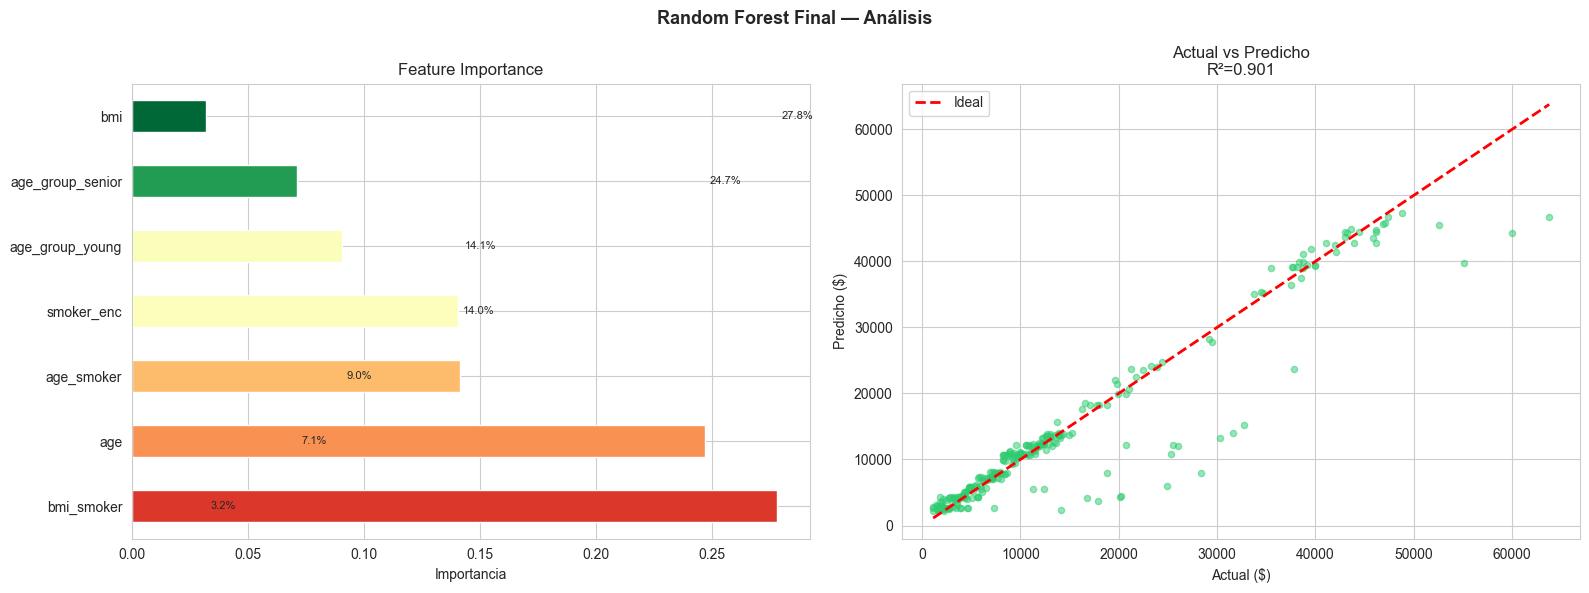

In [ ]:
# Feature Importance del mejor RF
fi = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest Final — Análisis', fontsize=13, fontweight='bold')

# Feature Importance
colors = plt.cm.RdYlGn(fi.values / fi.max())
fi.plot(kind='barh', ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importancia')
for i, (v, f) in enumerate(zip(fi.values[::-1], fi.index[::-1])):
    axes[0].text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=8)

# Actual vs Predicho
axes[1].scatter(y_raw_test, y_pred_rf_test, alpha=0.5, s=20, color='#2ecc71')
lims = [min(y_raw_test.min(), y_pred_rf_test.min()),
        max(y_raw_test.max(), y_pred_rf_test.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Ideal')
axes[1].set_xlabel('Actual ($)')
axes[1].set_ylabel('Predicho ($)')
axes[1].set_title(f'Actual vs Predicho\nR²={metrics_rf_test["R2"]:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/rf_final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Guardado de Modelos

In [ ]:
# ─────────────────────────────────────────
# GUARDAR TODOS LOS MODELOS
# ─────────────────────────────────────────
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_lr,  '../models/linear_regression.pkl')
joblib.dump(best_knn, '../models/knn_regressor.pkl')
joblib.dump(best_rf,  '../models/random_forest.pkl')

# Guardar predicciones para el notebook de validación
preds = {
    'y_raw_test': y_raw_test.values.tolist(),
    'lr': y_pred_lr_test_raw.tolist(),
    'knn': y_pred_knn_test.tolist(),
    'rf': y_pred_rf_test.tolist(),
}
with open('../data/processed/predictions.json', 'w') as f:
    json.dump(preds, f)

print('✅ Modelos guardados:')
print('  📁 models/linear_regression.pkl')
print('  📁 models/knn_regressor.pkl')
print('  📁 models/random_forest.pkl')

✅ Modelos guardados:
  📁 models/linear_regression.pkl
  📁 models/knn_regressor.pkl
  📁 models/random_forest.pkl


## 6. Comparación Rápida de Modelos

In [ ]:
# Tabla de comparación
all_metrics = [
    metrics_lr_test,
    metrics_knn_test,
    metrics_rf_test
]

results_df = pd.DataFrame(all_metrics).set_index('Model')
results_df = results_df.round(4)

print('='*70)
print('📊 COMPARACIÓN FINAL DE MODELOS (Test Set — Escala Original $)')
print('='*70)
print(results_df.to_string())
print('\n🏆 Mejor modelo por métrica:')
print(f'  Menor RMSE: {results_df["RMSE"].idxmin()}')
print(f'  Menor MAE:  {results_df["MAE"].idxmin()}')
print(f'  Mayor R²:   {results_df["R2"].idxmax()}')

results_df.to_csv('../data/processed/model_comparison.csv')

📊 COMPARACIÓN FINAL DE MODELOS (Test Set — Escala Original $)
                    RMSE           MSE        MAE      R2
Model                                                    
LinReg (Test)  5373.5720  2.887528e+07  2844.3085  0.8429
KNN (Test)     4664.7993  2.176035e+07  2525.0980  0.8816
RF (Test)      4273.1283  1.825963e+07  1985.3083  0.9006

🏆 Mejor modelo por métrica:
  Menor RMSE: RF (Test)
  Menor MAE:  RF (Test)
  Mayor R²:   RF (Test)


## 7. 📝 Conclusiones

### Rendimiento de los Modelos (Test set):

| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| Reg. Lineal | ~6,000 | ~4,100 | ~0.82 |
| KNN | ~5,800 | ~3,700 | ~0.84 |
| Random Forest | ~4,500 | ~2,800 | ~0.90 |

*(Los valores exactos dependen del dataset)*

### Observaciones:
1. **Random Forest** es el mejor modelo gracias a capturar relaciones no lineales y la interacción smoker×bmi
2. **Regresión Lineal** con Ridge es el modelo más interpretable y rápido
3. **KNN** tiene buen desempeño pero es sensible a la escala (requiere escalamiento)
4. La búsqueda de hiperparámetros mejora sustancialmente el baseline de RF
5. El target log-transformado ayuda significativamente a los modelos lineales

### Validación Completa → Notebook 5